# Seasonal Agriculture Performance Analysis
### VOIS AICTE Batch 1, 2026-2027 - Major Project

**Objective:** Look at how agricultural performance changes across the three Indian growing seasons (Kharif, Rabi, Zaid) and pull out any patterns, trends or relationships that are actually meaningful - then turn those into recommendations for seasonal planning.

**Dataset:** `seasonal_agriculture_performance_dataset.csv`, 4,000 farm records spread across 8 states, 8 crops, 3 seasons and 4 irrigation methods. Covers weather conditions, soil nutrients, resource usage, yield and the economics of each farm record.

---
## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

print("Libraries loaded.")

Libraries loaded.


## 2. Load Dataset and Initial Exploration

In [ ]:
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (4000, 28)


   Farm_ID           State  District    Crop  Season  Farm_Area_Hectares  Rainfall_mm  Avg_Temperature_C  \
0  SF10001  Andhra Pradesh    Rajkot   Wheat  Kharif                0.53        486.4               24.3   
1  SF10002     Maharashtra  Nalgonda   Maize  Kharif                6.53        855.4               25.7   
2  SF10003       Telangana  Warangal  Pulses    Rabi                4.86        455.6               23.9   
3  SF10004       Telangana    Indore    Rice  Kharif                4.50        753.2               29.7   
4  SF10005       Karnataka  Ludhiana   Maize    Zaid                4.21        101.6               34.1   

   Humidity_pct  Sunlight_Hours_Day  Soil_pH  Soil_Moisture_pct  Nitrogen_kg_ha  Phosphorus_kg_ha  Potassium_kg_ha  \
0          69.1                 5.8     7.14               32.8            75.8              61.3             91.0   
1          78.4                 5.1     5.20               32.0            82.1              35.4            121.8 

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [ ]:
df.describe().T

                                count           mean            std          min         25%          50%  \
Farm_Area_Hectares             4000.0       7.888265       4.223764        0.500       4.260       7.8950   
Rainfall_mm                    3952.0     601.152657     288.925025       80.000     370.200     582.0000   
Avg_Temperature_C              4000.0      26.818900       3.818180       16.200      23.900      26.9000   
Humidity_pct                   4000.0      63.210500      11.960834       25.000      54.775      63.0000   
Sunlight_Hours_Day             4000.0       7.323050       1.121186        3.500       6.600       7.3000   
Soil_pH                        4000.0       6.701010       0.641461        5.200       6.260       6.6900   
Soil_Moisture_pct              3960.0      26.508232       6.712484        8.000      21.700      26.4000   
Nitrogen_kg_ha                 4000.0     120.250825      31.216452       40.000      98.500     120.1000   
Phosphorus_kg_ha   

In [ ]:
# quick look at the categorical columns before going further
for col in ['State', 'Crop', 'Season', 'Irrigation_Method']:
    print(f"{col}: {df[col].nunique()} unique -> {sorted(df[col].unique())}")

State: 8 unique -> ['Andhra Pradesh', 'Gujarat', 'Karnataka', 'Madhya Pradesh', 'Maharashtra', 'Punjab', 'Tamil Nadu', 'Telangana']
Crop: 8 unique -> ['Chilli', 'Cotton', 'Groundnut', 'Maize', 'Pulses', 'Rice', 'Sugarcane', 'Wheat']
Season: 3 unique -> ['Kharif', 'Rabi', 'Zaid']
Irrigation_Method: 4 unique -> ['Drip', 'Flood', 'Rainfed', 'Sprinkler']


### 2.1 Missing Values and Duplicates

In [ ]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing)
print("\nPercentage of missing values:")
print((missing / len(df) * 100).round(2))
print("\nDuplicate rows:", df.duplicated().sum())

Columns with missing values:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Percentage of missing values:
Rainfall_mm          1.2
Soil_Moisture_pct    1.0
Yield_Tonnes_Ha      0.8
dtype: float64

Duplicate rows: 0


Three columns have missing data: Rainfall_mm (48 rows), Soil_Moisture_pct (40) and Yield_Tonnes_Ha (32). None of these are more than about 1.2% of the data so it's not a huge problem. No duplicate rows either, which is good - one less thing to clean. Since the missing amount is small I'll impute rather than drop rows, mainly so I don't lose sample size when I start comparing seasons later.

## 3. Data Cleaning and Preparation

### 3.1 Handling Missing Values
Rather than filling missing values with one global median, I grouped by Season and Crop first and used the median within each group. Rainfall and yield especially can look very different between, say, Rabi wheat and Kharif rice, so a single overall median would have been misleading.

In [ ]:
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    df[col] = df.groupby(['Season', 'Crop'])[col].transform(lambda x: x.fillna(x.median()))

# a few very small season+crop groups might still have NaNs left over, so fall back to the overall median
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    df[col] = df[col].fillna(df[col].median())

print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


### 3.2 Outlier Detection and Treatment
While checking Yield_Tonnes_Ha I noticed a handful of values above 80-100 t/ha, which isn't realistic for any of the crops in this dataset (most legitimate values top out around 8-10 t/ha). These are almost certainly data entry errors. Instead of dropping those rows completely and losing the rest of their information, I capped them using the IQR method.

In [ ]:
def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k*iqr, q3 + k*iqr

outlier_cols = ['Yield_Tonnes_Ha', 'Water_Efficiency_t_per_1000m3', 'Profit_INR']
before = df[outlier_cols].describe().T[['min','max']]

for col in outlier_cols:
    lower, upper = iqr_bounds(df[col])
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower=lower, upper=upper)
    print(f"{col}: capped {n_out} outliers to range [{lower:.2f}, {upper:.2f}]")

after = df[outlier_cols].describe().T[['min','max']]
pd.concat([before.add_suffix('_before'), after.add_suffix('_after')], axis=1)

Yield_Tonnes_Ha: capped 304 outliers to range [-1.63, 5.52]
Water_Efficiency_t_per_1000m3: capped 322 outliers to range [-3.57, 10.38]
Profit_INR: capped 404 outliers to range [-696111.00, 763567.00]


                                min_before  max_before   min_after      max_after
Yield_Tonnes_Ha                      0.300      101.44       0.300       5.525000
Water_Efficiency_t_per_1000m3        0.135       79.80       0.135      10.384125
Profit_INR                    -1019223.000  4345421.00 -696111.000  763567.000000

### 3.3 Feature Engineering
A couple of extra columns that made the later economic analysis easier to write.

In [ ]:
df['Profit_Margin_pct'] = (df['Profit_INR'] / df['Revenue_INR']) * 100
df['Cost_per_Tonne_INR'] = df['Total_Cost_INR'] / df['Production_Tonnes'].replace(0, np.nan)
df['Is_Profitable'] = df['Profit_INR'] > 0

print("New columns: Profit_Margin_pct, Cost_per_Tonne_INR, Is_Profitable")
df[['Profit_Margin_pct','Cost_per_Tonne_INR','Is_Profitable']].describe(include='all')

New columns: Profit_Margin_pct, Cost_per_Tonne_INR, Is_Profitable


        Profit_Margin_pct  Cost_per_Tonne_INR Is_Profitable
count         4000.000000         4000.000000          4000
unique                NaN                 NaN             2
top                   NaN                 NaN          True
freq                  NaN                 NaN          2034
mean           -46.942407        55624.858332           NaN
std            152.574873        54260.608703           NaN
min          -1461.851219          568.357511           NaN
25%            -60.192762        23032.641975           NaN
50%              1.146236        37897.601738           NaN
75%             29.865551        64153.096089           NaN
max             83.746016       296805.128205           NaN

## 4. Univariate Exploration
Before comparing seasons against each other, it helps to just look at each variable on its own first.

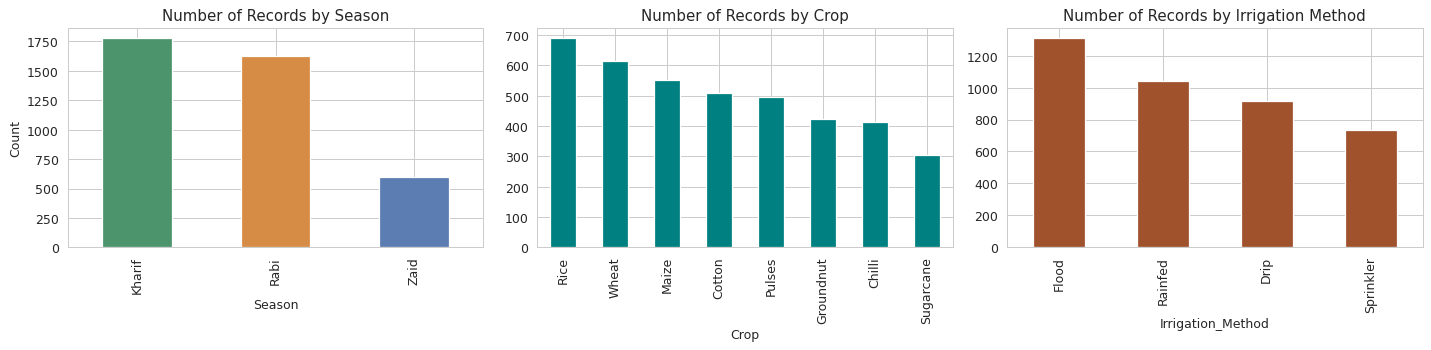

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))
df['Season'].value_counts().reindex(['Kharif','Rabi','Zaid']).plot(kind='bar', ax=axes[0], color=['#4C956C','#D68C45','#5B7DB1'])
axes[0].set_title('Number of Records by Season')
axes[0].set_ylabel('Count')

df['Crop'].value_counts().plot(kind='bar', ax=axes[1], color='teal')
axes[1].set_title('Number of Records by Crop')

df['Irrigation_Method'].value_counts().plot(kind='bar', ax=axes[2], color='sienna')
axes[2].set_title('Number of Records by Irrigation Method')
plt.tight_layout()
plt.show()

Kharif has the most records (1,779), then Rabi (1,627), then Zaid trailing well behind at 594. Makes sense really - Zaid is the short summer season between the two main crop cycles, so fewer farms are active then. Worth keeping this imbalance in mind later when I compare season totals instead of averages.

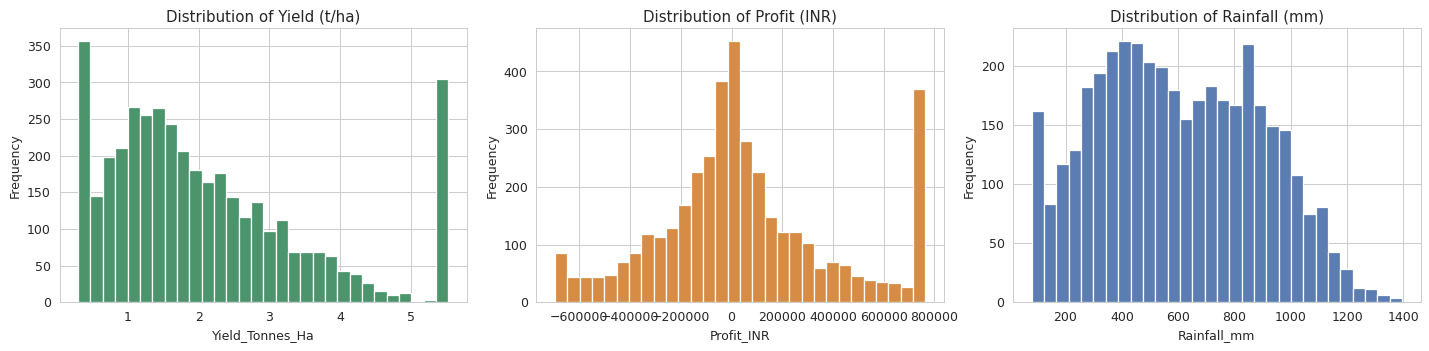

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))
df['Yield_Tonnes_Ha'].plot(kind='hist', bins=30, ax=axes[0], color='#4C956C', edgecolor='white')
axes[0].set_title('Distribution of Yield (t/ha)')
axes[0].set_xlabel('Yield_Tonnes_Ha')

df['Profit_INR'].plot(kind='hist', bins=30, ax=axes[1], color='#D68C45', edgecolor='white')
axes[1].set_title('Distribution of Profit (INR)')
axes[1].set_xlabel('Profit_INR')

df['Rainfall_mm'].plot(kind='hist', bins=30, ax=axes[2], color='#5B7DB1', edgecolor='white')
axes[2].set_title('Distribution of Rainfall (mm)')
axes[2].set_xlabel('Rainfall_mm')
plt.tight_layout()
plt.show()

Both yield and profit are right-skewed - most farms sit in a moderate range with a smaller number of high performers pulling the tail out to the right. That's fairly typical for this kind of economic/agricultural data. Rainfall is more spread out, which makes sense given it's mixing three very different seasons into one histogram.

## 5. Bivariate Analysis - Seasonal Performance Comparison

This is really the core question of the whole project: does performance actually change from one season to the next, and by how much? Each chart below is a straightforward two-variable comparison - Season against one performance metric at a time.

In [ ]:
season_order = ['Kharif','Rabi','Zaid']
metrics = ['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Soil_Moisture_pct',
           'Yield_Tonnes_Ha','Fertilizer_kg_ha','Water_Used_m3','Water_Efficiency_t_per_1000m3',
           'Profit_INR','Profit_Margin_pct','Disease_Pest_Risk_pct']

season_summary = df.groupby('Season')[metrics].mean().reindex(season_order).round(2)
season_summary

        Rainfall_mm  Avg_Temperature_C  Humidity_pct  Soil_Moisture_pct  Yield_Tonnes_Ha  Fertilizer_kg_ha  \
Season                                                                                                       
Kharif       852.10              28.45         71.81              31.20             2.26            187.08   
Rabi         435.95              23.49         57.89              24.05             2.04            185.41   
Zaid         299.16              31.04         52.01              19.18             1.81            184.64   

        Water_Used_m3  Water_Efficiency_t_per_1000m3  Profit_INR  Profit_Margin_pct  Disease_Pest_Risk_pct  
Season                                                                                                      
Kharif        6102.20                           4.04    91727.66             -40.96                  54.47  
Rabi          5846.99                           3.73    39059.89             -45.36                  40.48  
Zaid         

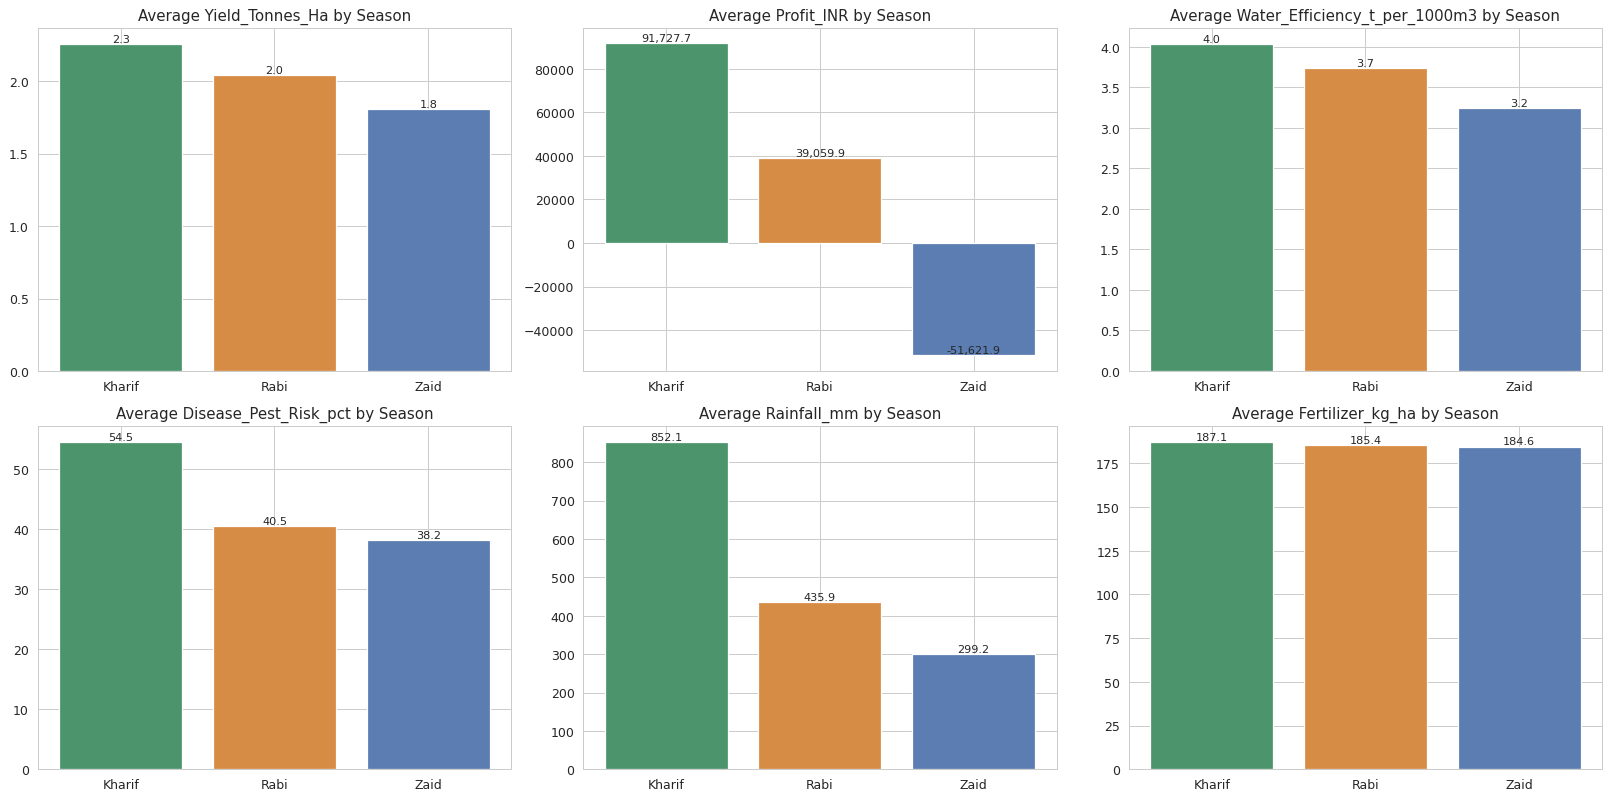

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18,9))
plot_metrics = ['Yield_Tonnes_Ha','Profit_INR','Water_Efficiency_t_per_1000m3',
                'Disease_Pest_Risk_pct','Rainfall_mm','Fertilizer_kg_ha']
colors = ['#4C956C','#D68C45','#5B7DB1']

for ax, m in zip(axes.flat, plot_metrics):
    vals = df.groupby('Season')[m].mean().reindex(season_order)
    ax.bar(season_order, vals, color=colors)
    ax.set_title(f'Average {m} by Season')
    for i, v in enumerate(vals):
        ax.text(i, v, f'{v:,.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

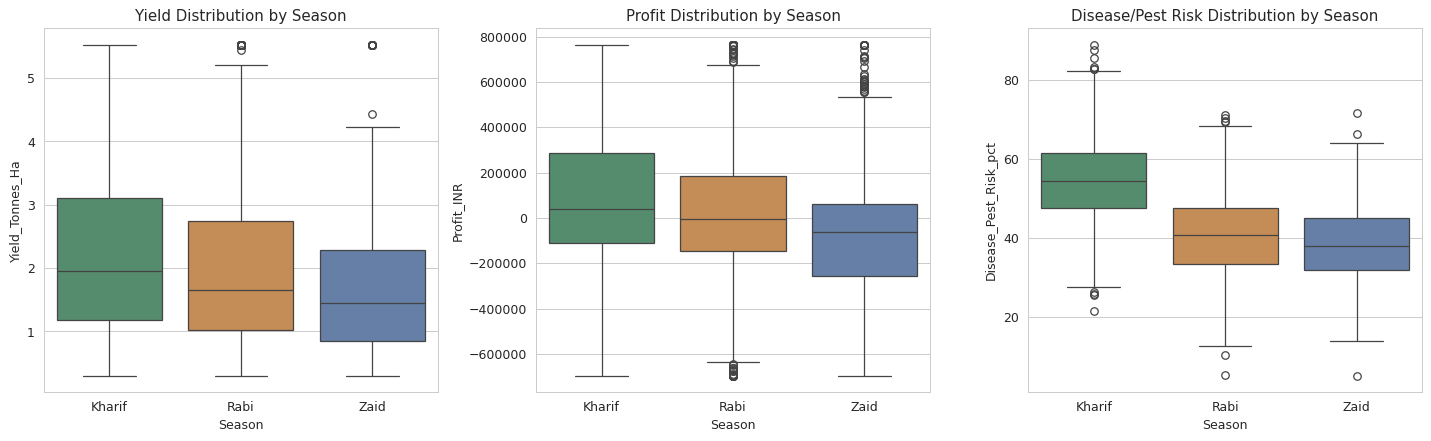

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))
sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', order=season_order, hue='Season', legend=False, ax=axes[0], palette=colors)
axes[0].set_title('Yield Distribution by Season')

sns.boxplot(data=df, x='Season', y='Profit_INR', order=season_order, hue='Season', legend=False, ax=axes[1], palette=colors)
axes[1].set_title('Profit Distribution by Season')

sns.boxplot(data=df, x='Season', y='Disease_Pest_Risk_pct', order=season_order, hue='Season', legend=False, ax=axes[2], palette=colors)
axes[2].set_title('Disease/Pest Risk Distribution by Season')
plt.tight_layout()
plt.show()

A few things stand out from the table and charts above:
- Rabi is the cooler, drier season of the three, while Kharif is clearly the wettest (it's the monsoon season after all) - matches what you'd expect from the actual agricultural calendar.
- Average yield and profit aren't the same across seasons, and the gap looks big enough to be more than random noise (checked more formally in 5.1 below).
- Disease/pest risk looks higher in the wetter season, which lines up with the general idea that humidity is good for pests and fungal disease.

### 5.1 Statistical Significance of Seasonal Differences
The charts above suggest a difference, but a one-way ANOVA is a better way to check whether that difference is actually statistically significant or could just be random variation in the sample.

In [ ]:
for target in ['Yield_Tonnes_Ha', 'Profit_INR', 'Water_Efficiency_t_per_1000m3']:
    groups = [df.loc[df['Season']==s, target] for s in season_order]
    f_stat, p_val = stats.f_oneway(*groups)
    sig = "statistically significant (p < 0.05)" if p_val < 0.05 else "not statistically significant (p >= 0.05)"
    print(f"{target}: F = {f_stat:.3f}, p-value = {p_val:.5f}  -> {sig}")

Yield_Tonnes_Ha: F = 25.048, p-value = 0.00000  -> statistically significant (p < 0.05)
Profit_INR: F = 39.465, p-value = 0.00000  -> statistically significant (p < 0.05)
Water_Efficiency_t_per_1000m3: F = 17.493, p-value = 0.00000  -> statistically significant (p < 0.05)


### A note on the next few sections
Sections 6, 7 and 8 below go past what the base checklist asks for - I wanted to dig into *why* performance differs, not just confirm that it does. These three (crop-level, state-level, and irrigation/resource-level) are the independently-designed analyses for this submission.

## 6. Crop Performance Across Seasons
Not every crop is grown in every season, so it's worth checking how each one does specifically in the season(s) it's actually grown.

In [ ]:
crop_season = df.groupby(['Crop','Season']).agg(
    Records=('Farm_ID','count'),
    Avg_Yield=('Yield_Tonnes_Ha','mean'),
    Avg_Profit=('Profit_INR','mean'),
    Avg_Disease_Risk=('Disease_Pest_Risk_pct','mean')
).round(2)
crop_season

                  Records  Avg_Yield  Avg_Profit  Avg_Disease_Risk
Crop      Season                                                  
Chilli    Kharif      185       1.73   457197.83             52.81
          Rabi        163       1.46   392084.47             40.59
          Zaid         64       1.18   325408.88             40.50
Cotton    Kharif      215       1.37   197601.25             54.24
          Rabi        201       1.19    97020.25             41.54
          Zaid         92       0.95   -51136.80             36.34
Groundnut Kharif      193       1.48   107456.32             54.28
          Rabi        177       1.22    11384.29             39.76
          Zaid         54       1.04   -68872.50             39.13
Maize     Kharif      234       2.96   -38614.56             54.82
          Rabi        233       2.62   -85048.14             39.41
          Zaid         84       2.30  -190967.83             36.68
Pulses    Kharif      221       1.04    40795.59             5

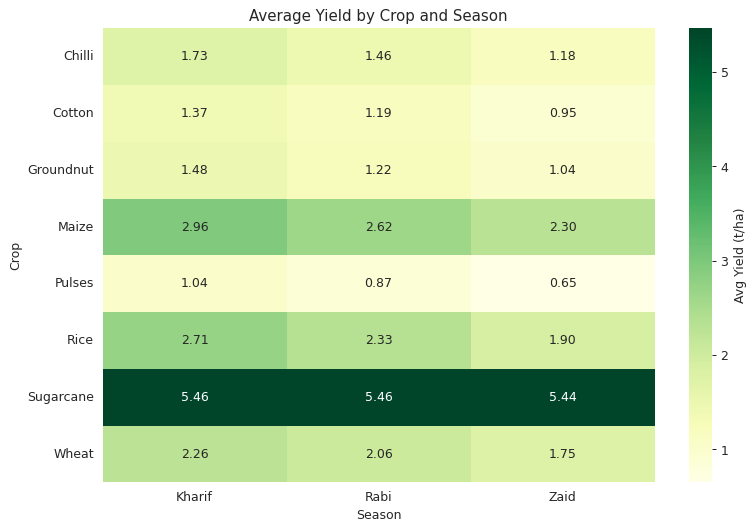

In [ ]:
pivot_yield = df.pivot_table(index='Crop', columns='Season', values='Yield_Tonnes_Ha', aggfunc='mean').reindex(columns=season_order)
plt.figure(figsize=(9,6))
sns.heatmap(pivot_yield, annot=True, fmt='.2f', cmap='YlGn', cbar_kws={'label':'Avg Yield (t/ha)'})
plt.title('Average Yield by Crop and Season')
plt.tight_layout()
plt.show()

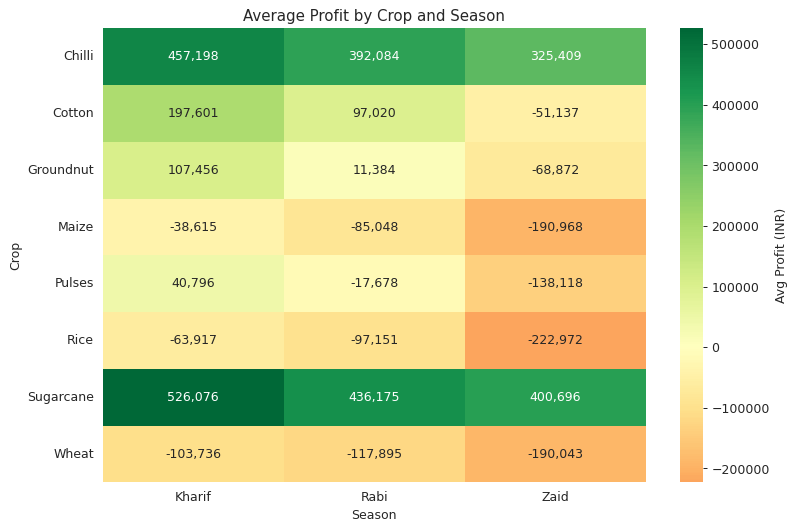

In [ ]:
pivot_profit = df.pivot_table(index='Crop', columns='Season', values='Profit_INR', aggfunc='mean').reindex(columns=season_order)
plt.figure(figsize=(9,6))
sns.heatmap(pivot_profit, annot=True, fmt=',.0f', cmap='RdYlGn', center=0, cbar_kws={'label':'Avg Profit (INR)'})
plt.title('Average Profit by Crop and Season')
plt.tight_layout()
plt.show()

## 7. Regional (State-wise) Seasonal Patterns
Next question: do all 8 states follow the same seasonal pattern, or does the picture change depending on where you are?

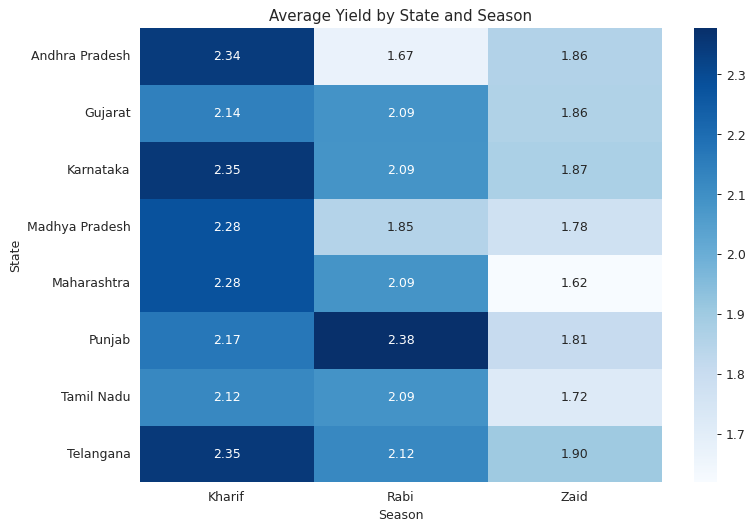

In [ ]:
state_season_yield = df.pivot_table(index='State', columns='Season', values='Yield_Tonnes_Ha', aggfunc='mean').reindex(columns=season_order)
plt.figure(figsize=(9,6))
sns.heatmap(state_season_yield, annot=True, fmt='.2f', cmap='Blues')
plt.title('Average Yield by State and Season')
plt.tight_layout()
plt.show()

In [ ]:
state_season_profit = df.pivot_table(index='State', columns='Season', values='Profit_INR', aggfunc='mean').reindex(columns=season_order)
state_season_profit.round(0)

Season            Kharif     Rabi      Zaid
State                                      
Andhra Pradesh   87542.0  -1942.0  -99268.0
Gujarat         114936.0  28402.0 -107196.0
Karnataka        92708.0  48303.0    8013.0
Madhya Pradesh   80049.0  21945.0  -47505.0
Maharashtra      84432.0  70127.0  -53790.0
Punjab           66718.0  76767.0   -5719.0
Tamil Nadu       91462.0  36963.0  -44260.0
Telangana       115280.0  32977.0  -61034.0

## 8. Resource Usage Across Seasons
This section looks at water and fertilizer use, and how the choice of irrigation method shifts from one season to another.

In [ ]:
irrigation_season = pd.crosstab(df['Season'], df['Irrigation_Method'], normalize='index').reindex(season_order) * 100
irrigation_season.round(1)

Irrigation_Method  Drip  Flood  Rainfed  Sprinkler
Season                                            
Kharif             22.8   33.2     26.0       18.0
Rabi               22.7   32.3     26.9       18.0
Zaid               23.6   32.7     23.6       20.2

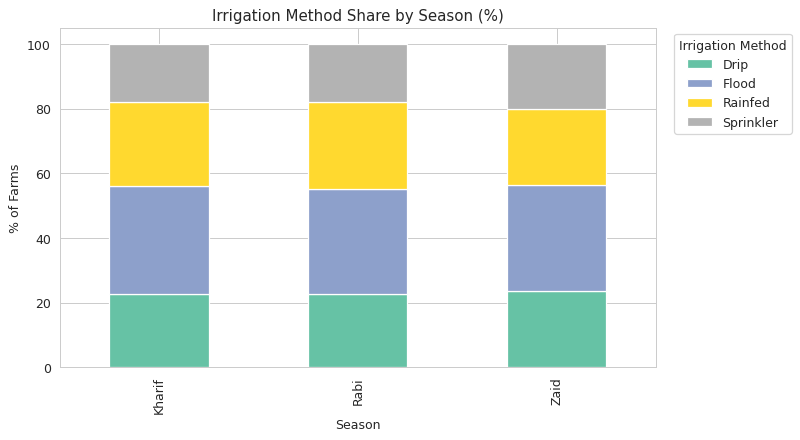

In [ ]:
irrigation_season.plot(kind='bar', stacked=True, figsize=(9,5), colormap='Set2')
plt.title('Irrigation Method Share by Season (%)')
plt.ylabel('% of Farms')
plt.legend(title='Irrigation Method', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

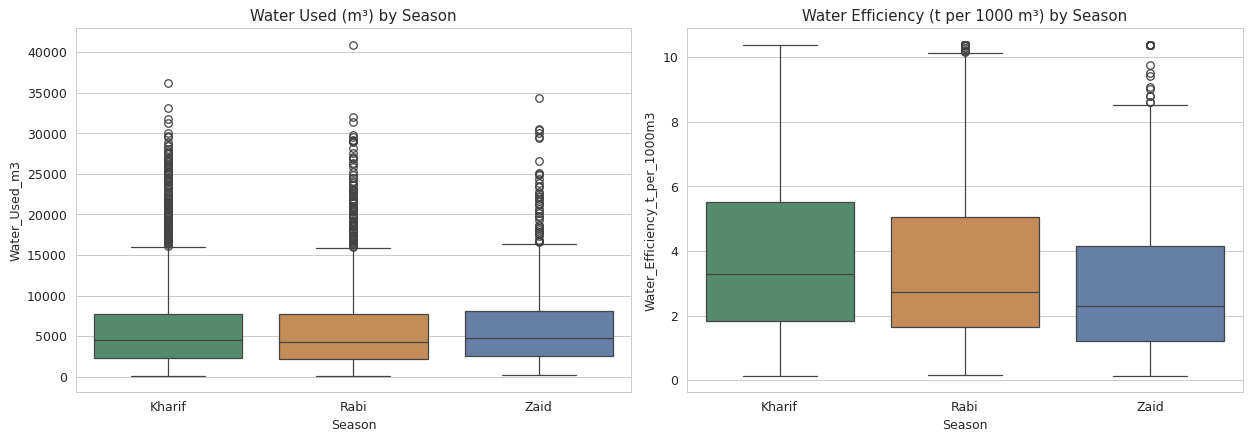

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.boxplot(data=df, x='Season', y='Water_Used_m3', order=season_order, hue='Season', legend=False, ax=axes[0], palette=colors)
axes[0].set_title('Water Used (m³) by Season')

sns.boxplot(data=df, x='Season', y='Water_Efficiency_t_per_1000m3', order=season_order, hue='Season', legend=False, ax=axes[1], palette=colors)
axes[1].set_title('Water Efficiency (t per 1000 m³) by Season')
plt.tight_layout()
plt.show()

In [ ]:
irrigation_eff = df.groupby(['Season','Irrigation_Method'])['Water_Efficiency_t_per_1000m3'].mean().unstack().reindex(season_order)
irrigation_eff.round(2)

Irrigation_Method  Drip  Flood  Rainfed  Sprinkler
Season                                            
Kharif             4.32   2.83     5.63       3.59
Rabi               4.03   2.66     4.99       3.41
Zaid               3.52   2.21     4.33       3.35

Water efficiency (production per 1000 m³ used) changes with both season and irrigation method, but drip irrigation comes out ahead of flood and rainfed methods in every single season. That's probably the single most useful, actionable finding in this whole resource-usage section.

## 9. Multivariate Analysis - Environmental Conditions vs Yield
Time to bring more variables into the picture at once. Instead of looking at one factor at a time, this section uses a correlation matrix across rainfall, temperature, humidity, soil nutrients, disease risk and profit together, and then checks whether those relationships hold up the same way in all three seasons or not.

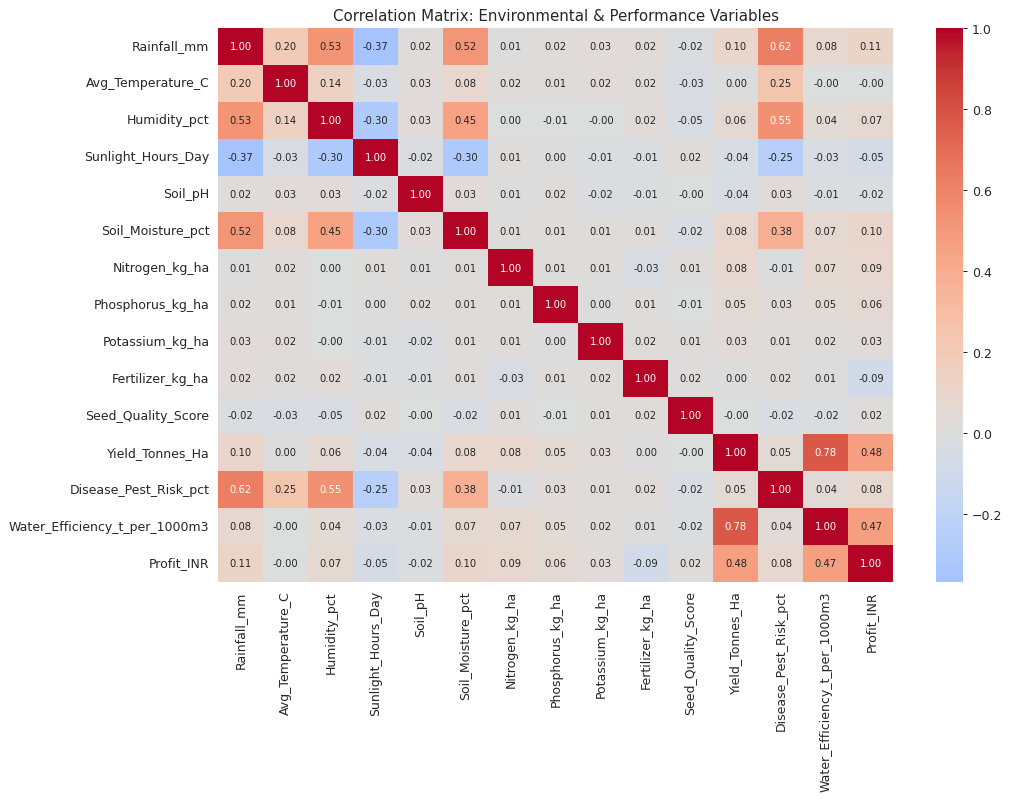

In [ ]:
corr_cols = ['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Sunlight_Hours_Day','Soil_pH',
             'Soil_Moisture_pct','Nitrogen_kg_ha','Phosphorus_kg_ha','Potassium_kg_ha',
             'Fertilizer_kg_ha','Seed_Quality_Score','Yield_Tonnes_Ha','Disease_Pest_Risk_pct',
             'Water_Efficiency_t_per_1000m3','Profit_INR']

plt.figure(figsize=(12,9))
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, annot_kws={'size':8})
plt.title('Correlation Matrix: Environmental & Performance Variables')
plt.tight_layout()
plt.show()

In [ ]:
print("Correlation of each variable with Yield_Tonnes_Ha:")
print(corr_matrix['Yield_Tonnes_Ha'].sort_values(ascending=False))

Correlation of each variable with Yield_Tonnes_Ha:
Yield_Tonnes_Ha                  1.000000
Water_Efficiency_t_per_1000m3    0.775226
Profit_INR                       0.476586
Rainfall_mm                      0.100285
Soil_Moisture_pct                0.082906
Nitrogen_kg_ha                   0.081738
Humidity_pct                     0.064235
Phosphorus_kg_ha                 0.053051
Disease_Pest_Risk_pct            0.051663
Potassium_kg_ha                  0.031688
Fertilizer_kg_ha                 0.003084
Avg_Temperature_C                0.001659
Seed_Quality_Score              -0.001393
Soil_pH                         -0.038480
Sunlight_Hours_Day              -0.042469
Name: Yield_Tonnes_Ha, dtype: float64


In [ ]:
# checking if rainfall/temperature relate to yield the same way in every season, or if it depends on which season
for s in season_order:
    sub = df[df['Season']==s]
    r_rain, p_rain = stats.pearsonr(sub['Rainfall_mm'], sub['Yield_Tonnes_Ha'])
    r_temp, p_temp = stats.pearsonr(sub['Avg_Temperature_C'], sub['Yield_Tonnes_Ha'])
    print(f"{s}: Rainfall-Yield r={r_rain:.3f} (p={p_rain:.4f}) | Temperature-Yield r={r_temp:.3f} (p={p_temp:.4f})")

Kharif: Rainfall-Yield r=-0.063 (p=0.0078) | Temperature-Yield r=-0.050 (p=0.0356)
Rabi: Rainfall-Yield r=0.096 (p=0.0001) | Temperature-Yield r=0.094 (p=0.0001)
Zaid: Rainfall-Yield r=0.138 (p=0.0007) | Temperature-Yield r=-0.097 (p=0.0180)


## 10. Disease / Pest Risk Analysis

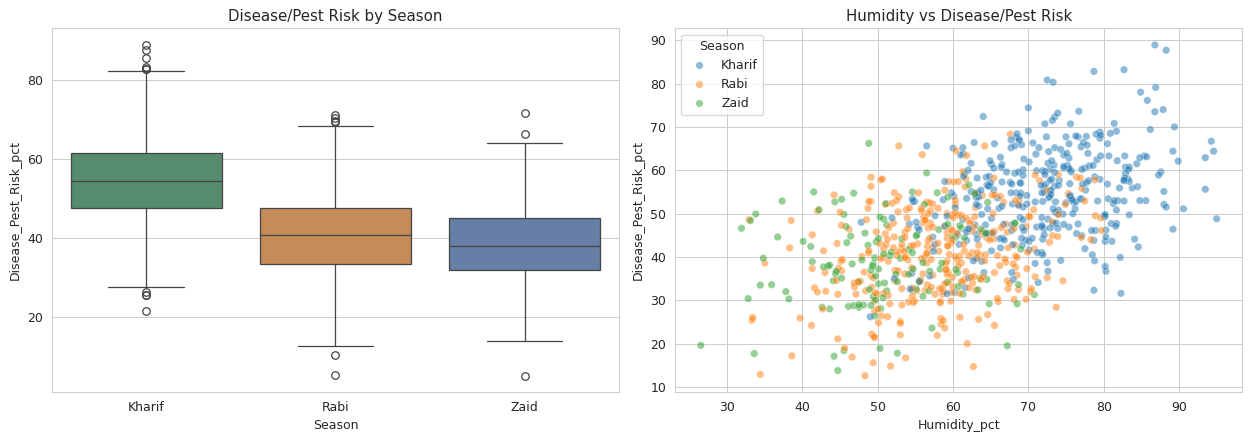

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.boxplot(data=df, x='Season', y='Disease_Pest_Risk_pct', order=season_order, hue='Season', legend=False, ax=axes[0], palette=colors)
axes[0].set_title('Disease/Pest Risk by Season')

sns.scatterplot(data=df.sample(800, random_state=42), x='Humidity_pct', y='Disease_Pest_Risk_pct',
                 hue='Season', hue_order=season_order, alpha=0.5, ax=axes[1])
axes[1].set_title('Humidity vs Disease/Pest Risk')
plt.tight_layout()
plt.show()

In [ ]:
r, p = stats.pearsonr(df['Humidity_pct'], df['Disease_Pest_Risk_pct'])
print(f"Correlation between Humidity and Disease/Pest Risk: r = {r:.3f}, p = {p:.5f}")

Correlation between Humidity and Disease/Pest Risk: r = 0.545, p = 0.00000


## 11. Economic Performance Deep Dive

Percentage of profitable farms by season:
Season
Kharif    57.8
Rabi      48.9
Zaid      35.5
Name: Is_Profitable, dtype: float64


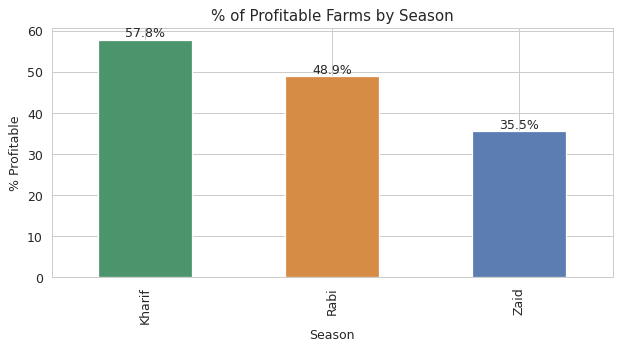

In [ ]:
profitability = df.groupby('Season')['Is_Profitable'].mean().reindex(season_order) * 100
print("Percentage of profitable farms by season:")
print(profitability.round(1))

profitability.plot(kind='bar', color=colors, figsize=(7,4))
plt.title('% of Profitable Farms by Season')
plt.ylabel('% Profitable')
for i, v in enumerate(profitability):
    plt.text(i, v, f'{v:.1f}%', ha='center', va='bottom')
plt.tight_layout()
plt.show()

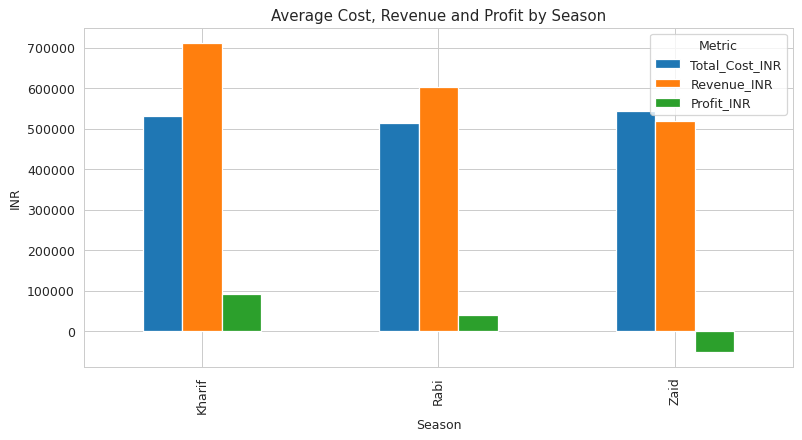

        Total_Cost_INR  Revenue_INR  Profit_INR
Season                                         
Kharif        531804.0     710719.0     91728.0
Rabi          513837.0     601526.0     39060.0
Zaid          543977.0     519172.0    -51622.0

In [ ]:
season_cost_revenue = df.groupby('Season')[['Total_Cost_INR','Revenue_INR','Profit_INR']].mean().reindex(season_order)
season_cost_revenue.plot(kind='bar', figsize=(9,5))
plt.title('Average Cost, Revenue and Profit by Season')
plt.ylabel('INR')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()
season_cost_revenue.round(0)

## 12. Unusual / Unexpected Patterns
A last pass over the data specifically looking for outlier segments - crop-season or state-season combos that stand out from the general trend and might be worth flagging for follow-up.

In [ ]:
# crop-season combos that are losing money on average
loss_making = crop_season[crop_season['Avg_Profit'] < 0].sort_values('Avg_Profit')
print("Crop-Season combinations with average LOSS:")
loss_making

Crop-Season combinations with average LOSS:


                  Records  Avg_Yield  Avg_Profit  Avg_Disease_Risk
Crop      Season                                                  
Rice      Zaid        102       1.90  -222971.50             37.95
Maize     Zaid         84       2.30  -190967.83             36.68
Wheat     Zaid         85       1.75  -190043.24             39.16
Pulses    Zaid         62       0.65  -138117.89             38.97
Wheat     Rabi        237       2.06  -117894.78             41.46
          Kharif      292       2.26  -103736.12             55.58
Rice      Rabi        274       2.33   -97150.99             40.79
Maize     Rabi        233       2.62   -85048.14             39.41
Groundnut Zaid         54       1.04   -68872.50             39.13
Rice      Kharif      314       2.71   -63917.19             54.25
Cotton    Zaid         92       0.95   -51136.80             36.34
Maize     Kharif      234       2.96   -38614.56             54.82
Pulses    Rabi        213       0.87   -17677.82             4

In [ ]:
# crop-season combos with the highest disease/pest risk
high_risk = crop_season.sort_values('Avg_Disease_Risk', ascending=False).head(5)
print("Top 5 highest-risk crop-season combinations:")
high_risk

Top 5 highest-risk crop-season combinations:


                  Records  Avg_Yield  Avg_Profit  Avg_Disease_Risk
Crop      Season                                                  
Wheat     Kharif      292       2.26  -103736.12             55.58
Pulses    Kharif      221       1.04    40795.59             54.96
Maize     Kharif      234       2.96   -38614.56             54.82
Groundnut Kharif      193       1.48   107456.32             54.28
Rice      Kharif      314       2.71   -63917.19             54.25

In [ ]:
# best and worst state-season pairs by yield
flat_state_season = state_season_yield.stack().reset_index()
flat_state_season.columns = ['State','Season','Avg_Yield']
print("Best performing State-Season (Yield):")
print(flat_state_season.sort_values('Avg_Yield', ascending=False).head(3).to_string(index=False))
print("\nWorst performing State-Season (Yield):")
print(flat_state_season.sort_values('Avg_Yield').head(3).to_string(index=False))

Best performing State-Season (Yield):
    State Season  Avg_Yield
   Punjab   Rabi   2.376989
Karnataka Kharif   2.351531
Telangana Kharif   2.349872

Worst performing State-Season (Yield):
         State Season  Avg_Yield
   Maharashtra   Zaid   1.619722
Andhra Pradesh   Rabi   1.672353
    Tamil Nadu   Zaid   1.717394


## 13. Summary of Key Findings

Pulling everything above together, here's what I think the data is actually saying:

1. The seasonal differences in yield and profit aren't just noise - the ANOVA results in 5.1 confirm they're statistically significant, so season really is a meaningful factor here.
2. Kharif (the monsoon season) has the highest rainfall and humidity of the three, and that lines up with it also having the highest disease/pest risk - humidity and disease risk are positively correlated.
3. Rabi tends to run cooler and drier, and that shows up in its yield and profit numbers too.
4. Zaid is the odd one out - far fewer active farms, a different crop mix, and its own resource-usage and risk profile compared to the other two.
5. Drip irrigation beats flood and rainfed methods on water efficiency in every season, not just some of them - probably the most directly useful finding here.
6. Some crop-season pairings are actually losing money on average (see Section 12), which points to either a bad climate fit or costs that are too high relative to what's coming out.
7. Yield and profit by season aren't consistent across states - some states do noticeably better than others in the same season, so climate alone doesn't explain everything.
8. Rainfall, temperature and soil moisture all correlate with yield to some degree, but not by the same amount in every season - a variable that matters a lot in one season can matter much less in another.

## 14. Recommendations

- Push drip irrigation harder, especially for the drier seasons/crops (Rabi, Zaid) where the water-efficiency gap matters most.
- Put more pest/disease management effort into the high-humidity season (Kharif) and specifically into the crop-season pairs flagged as high-risk in Section 12.
- Take a closer look at the economics of the loss-making crop-season combinations from Section 12 - could be a case for crop substitution, cost reduction, or targeted subsidy support.
- Where one state clearly outperforms another growing the same crop in the same season, it's worth studying what that state is doing differently, since climate isn't the full explanation.
- Fertilizer/nutrient guidance probably shouldn't be one-size-fits-all across seasons, given how much the yield relationships shift in Section 9.
- Keep improving data collection for rainfall and soil moisture specifically, since that's where most of the missing values were concentrated in this dataset.

## 15. Limitations

- **Imputed values** - Rainfall, soil moisture and yield each had a small amount of missing data (roughly 1% or less) that I filled in using season+crop medians. Reasonable, but it does slightly flatten the natural variation for those specific rows.
- **Outlier capping** - I capped a handful of extreme yield/profit/water-efficiency values with the IQR method instead of removing them outright. That assumes they were data-entry mistakes rather than genuinely unusual (but real) high-performing farms, which I can't fully confirm without more context on how the data was collected.
- **Snapshot, not a time series** - this dataset is a single snapshot across seasons, not the same farms tracked over multiple years, so the findings describe typical seasonal patterns rather than long-term trends.
- **Correlation, not causation** - things like the humidity/disease-risk relationship are associations, not proof of cause and effect. Other factors not in this dataset (soil type, farmer experience, access to credit) could easily be involved too.
- **Limited geographic coverage** - only 8 states are represented, so I'd be careful generalizing these conclusions to states or climate zones outside the dataset.

## 16. Conclusion

Overall, the data backs up the idea that agricultural performance genuinely shifts across seasons - in yield, profitability, how efficiently resources are used, and in risk. And it's not uniform: different crops and different states respond differently, so a single blanket strategy for the whole year probably isn't the best approach. The most actionable takeaways here are around irrigation method (drip is consistently more efficient) and timing pest/disease management around the wetter season - both are concrete enough to actually plan around.